# poly2mask.ipynb

In [ ]:
import numpy as np
import shapely.wkt as wkt
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd
from icecream import ic
import cv2
from skimage.measure import perimeter
import pyefd

# Functions

In [ ]:
def pad_to_square(binary_array, pad_value=0):
    """
    Pads a 2D numpy binary array to make it square.

    Args:
        binary_array (np.ndarray): The input 2D numpy array.
        pad_value (int): The constant value used for padding (0 or 1).

    Returns:
        np.ndarray: The padded square array.
    """
    height, width = binary_array.shape
    max_dim = max(height, width)
    
    # Calculate the padding needed for each axis
    # The padding is split evenly (as possible) between "before" and "after" the original array
    pad_height = max_dim - height
    pad_width = max_dim - width
    
    # Define padding for top/bottom and left/right
    # ((top, bottom), (left, right))
    # Using floor division to distribute padding
    top_pad = pad_height // 2
    bottom_pad = pad_height - top_pad
    left_pad = pad_width // 2
    right_pad = pad_width - left_pad
    
    pad_width_tuple = ((top_pad, bottom_pad), (left_pad, right_pad))
    
    # Pad the array using the 'constant' mode with the specified value
    padded_array = np.pad(binary_array, pad_width=pad_width_tuple, mode='constant', constant_values=pad_value)
    
    return padded_array

# # --- Example Usage ---
# # Create a non-square 2D binary array
# original_array = np.array([
#     [1, 0, 1],
#     [0, 1, 0]
# ])

# print("Original Array Shape:", original_array.shape)
# print(original_array)

# # Pad the array to make it square
# square_array = pad_to_square(original_array, pad_value=0)

# print("\nSquared Array Shape:", square_array.shape)
# print(square_array)

# # Another example with a different aspect ratio
# original_array_2 = np.array([
#     [1, 1],
#     [0, 0],
#     [1, 1],
#     [0, 0]
# ])

# print("\nOriginal Array 2 Shape:", original_array_2.shape)
# print(original_array_2)

# # Pad the second array
# square_array_2 = pad_to_square(original_array_2, pad_value=1)

# print("\nSquared Array 2 Shape:", square_array_2.shape)
# print(square_array_2)

In [67]:
import numpy as np
from shapely.geometry import Polygon

def calculate_polygon_iou(poly1_coords, poly2_coords):
    """
    Calculates the IoU of two polygons given as numpy arrays of coordinates.

    Args:
        poly1_coords (np.ndarray): Coordinates of the first polygon (Nx2 array).
        poly2_coords (np.ndarray): Coordinates of the second polygon (Mx2 array).

    Returns:
        float: The IoU score between 0.0 and 1.0.
    """
    # Convert numpy arrays to shapely Polygon objects
    polygon1 = Polygon(poly1_coords)
    polygon2 = Polygon(poly2_coords)

    # Check if polygons intersect to handle non-overlapping cases efficiently
    if not polygon1.intersects(polygon2):
        return 0.0

    # Calculate the intersection area
    intersection_area = polygon1.intersection(polygon2).area

    # Calculate the union area
    # A slightly faster way to calculate union area is: 
    # area(poly1) + area(poly2) - area(intersection)
    union_area = polygon1.area + polygon2.area - intersection_area
    
    # Compute IoU
    iou = intersection_area / union_area

    return iou

# Example Usage:
# Define two sample polygons as numpy arrays
# Polygon 1: A square from (0,0) to (2,2)
poly1_coords = np.array([[0, 0], [2, 0], [2, 2], [0, 2]])
# Polygon 2: Another square overlapping the first, from (1,1) to (3,3)
poly2_coords = np.array([[1, 1], [3, 1], [3, 3], [1, 3]])

# Calculate the IoU
iou_score = calculate_polygon_iou(poly1_coords, poly2_coords)
print(f"The IoU of the two polygons is: {iou_score}")

# Example with non-overlapping polygons
poly3_coords = np.array([[10, 10], [12, 10], [12, 12], [10, 12]])
iou_no_overlap = calculate_polygon_iou(poly1_coords, poly3_coords)
print(f"The IoU of the non-overlapping polygons is: {iou_no_overlap}")


The IoU of the two polygons is: 0.14285714285714285
The IoU of the non-overlapping polygons is: 0.0


# Main

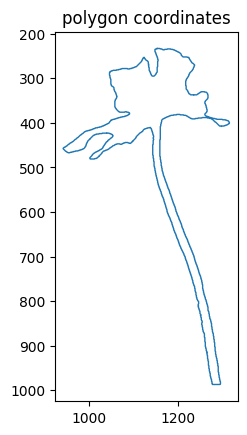

In [3]:
# Read WKT from SQLite and convert to Shapely geometry
df = pd.read_sql(
    "SELECT detection_id, poly_wkt FROM detections WHERE detection_id=17;", 
    sqlite3.connect('sam3_detections.sqlite3')
)
wkt_str = df.at[0, 'poly_wkt']
poly = wkt.loads(wkt_str)
x, y = poly.exterior.xy

# Plot
fig, ax = plt.subplots()
ax.plot(x, y, linewidth=1)
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_aspect('equal')
ax.set_title('polygon coordinates');

ic| coords[:10]: array([[211,   0],
                        [210,   1],
                        [208,   1],
                        [207,   2],
                        [206,   2],
                        [206,   7],
                        [207,   8],
                        [207,   9],
                        [208,  10],
                        [208,  12]], dtype=int32)
ic| np.max(coords, axis=0): array([373, 754], dtype=int32)
ic| coords[:10]: array([[211,   0],
                        [210,   1],
                        [208,   1],
                        [207,   2],
                        [206,   2],
                        [206,   7],
                        [207,   8],
                        [207,   9],
                        [208,  10],
                        [208,  12]], dtype=int32)
ic| np.max(coords, axis=0): array([373, 754], dtype=int32)
ic| min(xs): np.int32(0)
    max(xs): np.int32(373)
    min(ys): np.int32(0)
    max(ys): np.int32(754)


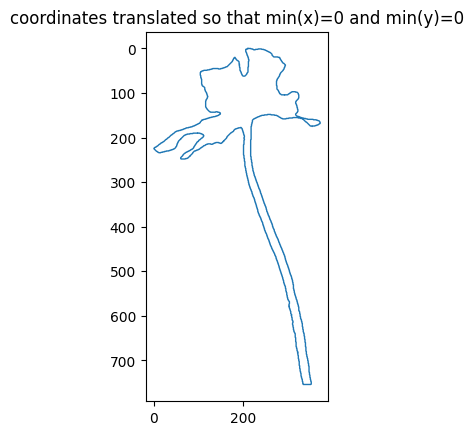

In [4]:
coords = np.array(poly.exterior.coords, dtype=np.int32)
coords = coords - np.min(coords, axis=0)
ic(coords[:10])
ic(np.max(coords, axis=0))

# coords = coords + 10
ic(coords[:10])
ic(np.max(coords, axis=0))
xs, ys = coords.T
ic(min(xs), max(xs), min(ys), max(ys))

fig, ax = plt.subplots()
ax.plot(xs, ys, linewidth=1)
ax.set_aspect('equal')
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_title('coordinates translated so that min(x)=0 and min(y)=0');

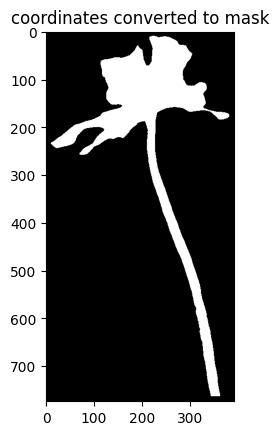

In [5]:
mask = cv2.fillPoly(np.zeros((max(ys), max(xs)), dtype=np.uint8), [coords], 1)
mask = np.pad(mask, pad_width=10, mode='constant', constant_values=0)

fig, ax = plt.subplots()
ax.imshow(mask, cmap='gray')
ax.set_title('coordinates converted to mask');

In [6]:
# Calculating ones in edges
arr = mask
top_ones = np.sum(arr[0, :])
bottom_ones = np.sum(arr[-1, :])
left_ones = np.sum(arr[:, 0])
right_ones = np.sum(arr[:, -1])
ic(top_ones, bottom_ones, left_ones, right_ones)

ic| top_ones: np.uint64(0)
    bottom_ones: np.uint64(0)
    left_ones: np.uint64(0)
    right_ones: np.uint64(0)


(np.uint64(0), np.uint64(0), np.uint64(0), np.uint64(0))

ic| mask.shape: (774, 393)
ic| perimeter(mask, neighborhood=4): np.float64(2759.54242277373)
ic| resized_mask.shape: (1080, 548)
ic| np.max(resized_mask): np.uint8(1)
ic| perimeter(resized_mask, neighborhood=4): np.float64(4027.4795436573277)


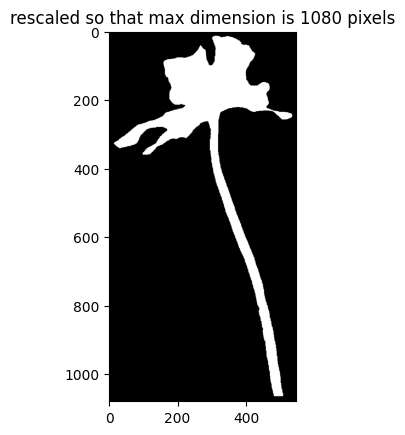

In [ ]:
height, width = mask.shape
ic(mask.shape)
ic(perimeter(mask, neighborhood=4) )

target_dimension = 1080
if height > width:
    ratio = target_dimension / float(height)
else:
    ratio = target_dimension / float(width) 
new_height = int(ratio * height)
new_width = int(ratio * width)
resized_mask = cv2.resize(mask, (new_width, new_height), interpolation=cv2.INTER_AREA)
ic(resized_mask.shape)
ic(np.max(resized_mask))
ic(perimeter(resized_mask, neighborhood=4) )

fig, ax = plt.subplots()
ax.imshow(resized_mask, cmap='gray')
ax.set_title('rescaled so that max dimension is 1080 pixels');

ic| squared_mask.shape: (1080, 1080)


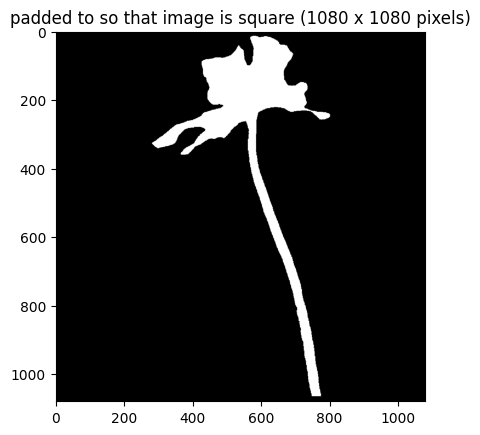

In [ ]:
squared_mask = pad_to_square(resized_mask)
ic(squared_mask.shape)

fig, ax = plt.subplots()
ax.imshow(squared_mask, cmap='gray')
ax.set_title('padded to so that image is square (1080 x 1080 pixels)');

ic| contour: array([[574,  14],
                    [573,  15],
                    [570,  15],
                    ...,
                    [588,  15],
                    [584,  15],
                    [583,  14]], shape=(1761, 2), dtype=int32)


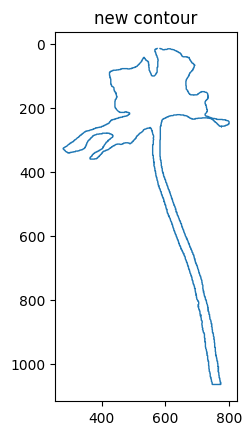

In [ ]:
# Get a contour for the square_mask and use it to calculate EFD coefficients

import cv2 
import numpy
from pyefd import elliptic_fourier_descriptors

im = squared_mask

# Find the contours of a binary image using OpenCV.
contours, hierarchy = cv2.findContours(
    im, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
assert len(contours) == 1
contour = contours[0].squeeze()
ic(contour)

# Plot
xs, ys = contour.T
fig, ax = plt.subplots()
ax.plot(xs, ys, linewidth=1)
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_aspect('equal')
ax.set_title('new contour');


In [ ]:
coeffs = pyefd.elliptic_fourier_descriptors(contour, order=70, normalize=False)
ic(coeffs.shape)
# print('coeffs:\n',coeffs)

# # coeffs = pyefd.normalize_efd(coeffs)
# # ic(coeffs.shape)
# # print('coeffs:\n',coeffs)

# a0, c0 = pyefd.calculate_dc_coefficients(contour)
# ic(a0, c0)
# pyefd.plot_efd(coeffs, locus=(a0,c0), contour=contour)


ic| coeffs.shape: (70, 4)


(70, 4)

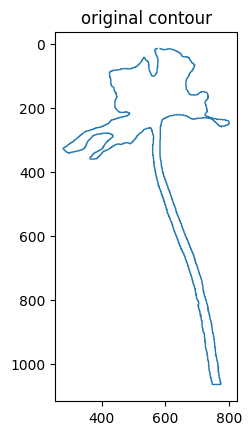

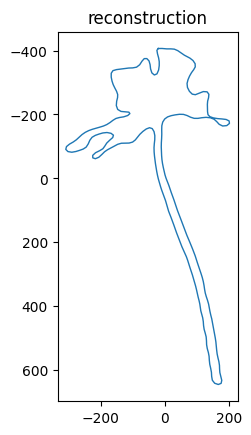

In [ ]:
# Plot
fig, ax = plt.subplots()
ax.plot(xs, ys, linewidth=1)
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_aspect('equal')
ax.set_title('original contour');

# Reconstruct contour using EFD coefficients
reconstructed_poly = pyefd.reconstruct_contour(coeffs)

# Plot
r_xs, r_ys = reconstructed_poly.T

fig, ax = plt.subplots()
ax.plot(r_xs, r_ys, linewidth=1)
ax.set_aspect('equal')
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_title('reconstruction');



0.8100316474445224

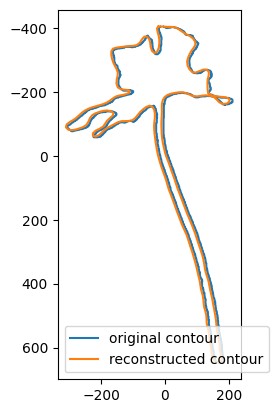

In [68]:
# plot reconstructed contour on top of original contour

# translate so that origins are at the centroid of each polygon
centered_contour = contour - np.mean(contour, axis=0)
centered_reconstructed_poly = reconstructed_poly - np.mean(reconstructed_poly, axis=0)

# extract arrays for xs and ys
contour_xs, contour_ys = centered_contour.T
reconstructed_xs, reconstructed_ys = centered_reconstructed_poly.T

# plot original contour and reconstructed contour in the same axes
fig, ax = plt.subplots()
fig.set
plt.plot(contour_xs, contour_ys, label='original contour')
plt.plot(reconstructed_xs, reconstructed_ys, label='reconstructed contour')
ax.set_aspect('equal')
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.legend(loc='best')

calculate_polygon_iou(centered_contour, centered_reconstructed_poly)
